
# Análise Não Supervisionada de Tráfego de Firewall

**Disciplina:** Aprendizado de Máquina Não Supervisionado (LT96013-00004-999995)
**Professor:** Cassiano Ricardo Neubauer Moralles
**Aluno:** _GUSTAVO MARTINS CONCEIÇÂO_
**Data:** Setembro/2026

## Objetivo

Este notebook aplica técnicas de aprendizado não supervisionado sobre um dataset real de
logs de firewall (`data/new_logs.csv`), contendo registros de tráfego permitido/negado,
regras de firewall, regras de NAT, interfaces, IPs, portas e protocolos.

**Etapas:**
1. Estatística descritiva do dataset;
2. Pré-processamento e engenharia de atributos;
3. Aplicação de 4 técnicas estudadas na disciplina, com justificativa de escolha:
   - **PCA** (redução de dimensionalidade);
   - **K-Means** (clusterização particional);
   - **DBSCAN** (clusterização baseada em densidade / detecção de anomalias);
   - **Avaliação de Clusters** (métricas quantitativas e validação cruzada com rótulos conhecidos).
4. Conclusões.



## Justificativa da escolha dos 4 algoritmos

O enunciado pede a aplicação de 4 das técnicas estudadas dentre: K-Means, Hierárquico,
DBSCAN, Avaliação de Clusters, PCA, Seleção de Características, T-SNE, Apriori e FP-Growth.
Optou-se por **PCA + K-Means + DBSCAN + Avaliação de Clusters** pelos seguintes motivos:

- O dataset é predominantemente categórico (protocolo, interfaces, nomes de regra, etc.),
  o que gera muitas colunas após one-hot encoding. **PCA** permite reduzir essa
  dimensionalidade, remover redundância/colinearidade entre atributos correlacionados
  (ex.: `Firewall rule` e `Firewall rule name` carregam a mesma informação) e viabilizar
  visualização 2D dos clusters.
- **K-Means** fornece uma baseline de clusterização particional, útil para segmentar o
  tráfego em grupos coesos (ex.: por combinação de regra/serviço/porta de destino).
- **DBSCAN** é  adequado para tráfego de rede porque não exige definir o
  número de clusters inicialmente e consegue isolar como *ruído* eventos fora do padrão 
  no dataset, apenas 4 de 200 registros são `Denied` e 2 são `Invalid Traffic`. Isso permite
  testar DBSCAN como detector de anomalias, comparando os pontos marcados como ruído com
  esses rótulos raros (que **não** são usados como feature de clusterização, apenas para
  validação).
- **Avaliação de Clusters** (Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz) é
  aplicada para justificar quantitativamente a escolha de hiperparâmetros (k do K-Means,
  eps/min_samples do DBSCAN) e comparar os dois algoritmos entre si.



## 1. Importação de bibliotecas

In [1]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 30)



## 2. Carregamento do dataset

O arquivo `data/new_logs.csv` contém logs de firewall exportados de um appliance de rede,
com colunas de tempo, regra de firewall, regra de NAT, interfaces, IPs/portas de origem e
destino, protocolo e o resultado da regra (permitido/negado).


In [2]:

df = pd.read_csv("../data/new_logs.csv")
df.columns = [c.strip() for c in df.columns]
print(df.shape)
df.head()


(200, 20)


,Time,Log comp,Log subtype,Username,Firewall rule,Firewall rule name,NAT rule,NAT rule name,In interface,Out interface,Src IP,Dst IP,Src port,Dst port,protocol,Rule type,Live PCAP,Message,Log occurrence,Unnamed: 19
0,2024-07-06 12:29:34,Firewall Rule,Allowed,NaN,5.0,WebNat,10,iqrad webserver - DNAT,Port2,Port3,45.147.66.142,82.213.48.193,4036,443,TCP,1,Open PCAP,NaN,1,NaN
1,2024-07-06 12:29:30,Firewall Rule,Allowed,NaN,48.0,DMZ-to-WAN,15,Default SNAT IPv4,Port3,Port2,172.17.17.8,10.101.6.4,52907,443,TCP,1,Open PCAP,NaN,1,NaN
2,2024-07-06 12:29:29,Firewall Rule,Allowed,NaN,2.0,LAN-2-WAN,15,Default SNAT IPv4,Port1,Port2,192.168.61.137,3.72.193.109,53382,443,TCP,1,Open PCAP,NaN,1,NaN
3,2024-07-06 12:29:29,Firewall Rule,Allowed,NaN,5.0,WebNat,10,iqrad webserver - DNAT,Port2,Port3,45.147.66.142,82.213.48.193,32034,443,TCP,1,Open PCAP,NaN,1,NaN
4,2024-07-06 12:29:29,Firewall Rule,Allowed,NaN,48.0,DMZ-to-WAN,14,PublicDNS - SNAT,Port3,Port2,172.17.17.223,23.196.143.19,49302,443,TCP,1,Open PCAP,NaN,1,NaN



## 3. Estatística Descritiva (item 2.a)


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Time                200 non-null    object 
 1   Log comp            200 non-null    object 
 2   Log subtype         200 non-null    object 
 3   Username            0 non-null      float64
 4   Firewall rule       198 non-null    float64
 5   Firewall rule name  198 non-null    object 
 6   NAT rule            200 non-null    int64  
 7   NAT rule name       192 non-null    object 
 8   In interface        198 non-null    object 
 9   Out interface       196 non-null    object 
 10  Src IP              200 non-null    object 
 11  Dst IP              200 non-null    object 
 12  Src port            200 non-null    int64  
 13  Dst port            200 non-null    int64  
 14  protocol            200 non-null    object 
 15  Rule type           200 non-null    int64  
 16  Live PCA

In [4]:

# Percentual de valores ausentes por coluna
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
missing.to_frame("% ausente")


,% ausente
Username,100.0
Unnamed: 19,100.0
Message,99.0
NAT rule name,4.0
Out interface,2.0
In interface,1.0
Firewall rule name,1.0
Firewall rule,1.0


In [5]:

# Colunas totalmente vazias ou constantes não agregam informação e serão descartadas
# mais adiante: Username (100% nula), Unnamed: 19 (100% nula), Live PCAP (constante),
# Log occurrence (constante), Message (99% nula)
for col in ["Username", "Unnamed: 19", "Live PCAP", "Log occurrence", "Message"]:
    print(col, "-> valores únicos:", df[col].dropna().unique()[:5], "| nulos:", df[col].isnull().sum())


Username -> valores únicos: [] | nulos: 200
Unnamed: 19 -> valores únicos: [] | nulos: 200
Live PCAP -> valores únicos: ['Open PCAP'] | nulos: 0
Log occurrence -> valores únicos: [1] | nulos: 0
Message -> valores únicos: ['IP packet with invalid header length.'
 'TCP Packets with invalid flag combination.'] | nulos: 198


In [6]:

df.describe(include=[np.number])


,Username,Firewall rule,NAT rule,Src port,Dst port,Rule type,Log occurrence,Unnamed: 19
count,0.0,198.000000,200.000000,200.000000,200.000000,200.000000,200.0,0.0
mean,NaN,24.969697,13.730000,51726.595000,250.520000,0.990000,1.0,NaN
std,NaN,22.613259,3.265027,11453.840349,306.720798,0.099748,0.0,NaN
min,NaN,2.000000,0.000000,0.000000,0.000000,0.000000,1.0,NaN
25%,NaN,2.000000,15.000000,52456.500000,53.000000,1.000000,1.0,NaN
50%,NaN,20.000000,15.000000,54160.500000,80.000000,1.000000,1.0,NaN
75%,NaN,48.000000,15.000000,54614.250000,443.000000,1.000000,1.0,NaN
max,NaN,55.000000,15.000000,65377.000000,3544.000000,1.000000,1.0,NaN


In [7]:

df.describe(include="object")


,Time,Log comp,Log subtype,Firewall rule name,NAT rule name,In interface,Out interface,Src IP,Dst IP,protocol,Live PCAP,Message
count,200,200,200,198,192,198,196,200,200,200,200,2
unique,101,2,2,10,4,3,2,24,58,3,1,2
top,2024-07-06 12:25:58,Firewall Rule,Allowed,LAN-2-WAN,Default SNAT IPv4,Port1,Port2,192.168.61.233,8.8.8.8,TCP,Open PCAP,IP packet with invalid header length.
freq,9,198,196,72,157,124,172,75,68,113,200,1


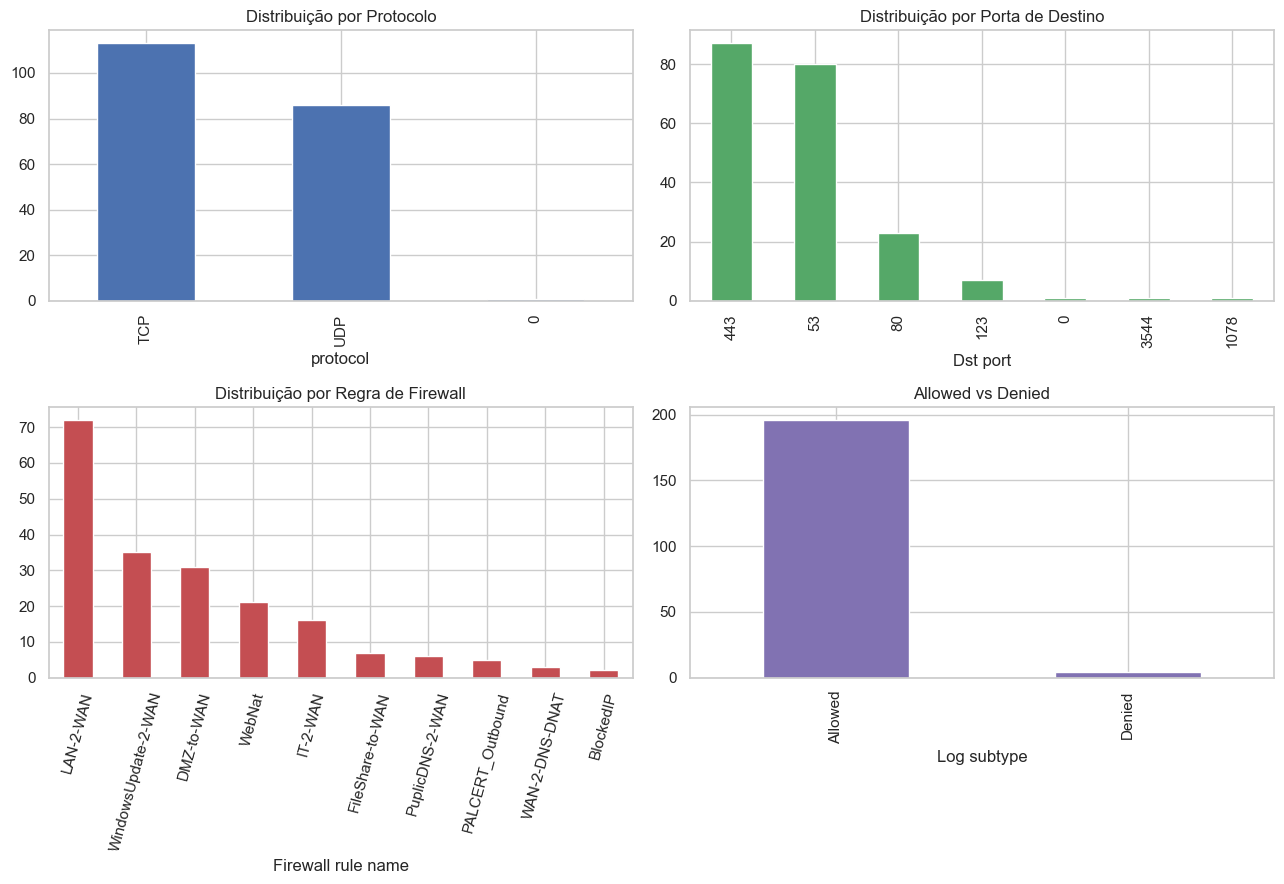

In [8]:

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

df["protocol"].value_counts().plot(kind="bar", ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Distribuição por Protocolo")

df["Dst port"].value_counts().plot(kind="bar", ax=axes[0, 1], color="#55A868")
axes[0, 1].set_title("Distribuição por Porta de Destino")

df["Firewall rule name"].value_counts().plot(kind="bar", ax=axes[1, 0], color="#C44E52")
axes[1, 0].set_title("Distribuição por Regra de Firewall")
axes[1, 0].tick_params(axis="x", rotation=75)

df["Log subtype"].value_counts().plot(kind="bar", ax=axes[1, 1], color="#8172B2")
axes[1, 1].set_title("Allowed vs Denied")

plt.tight_layout()
plt.show()


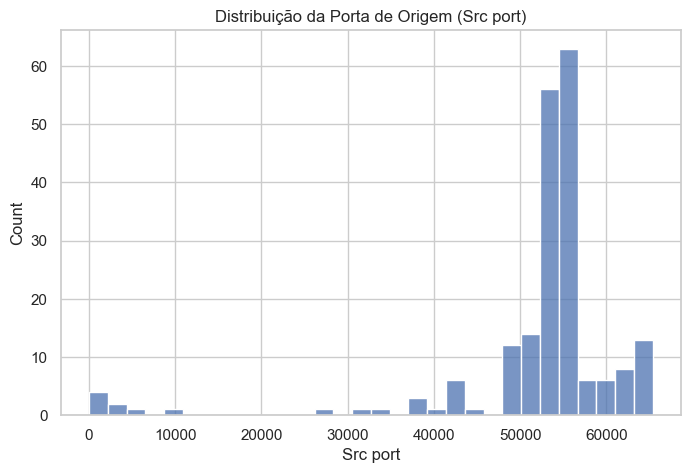

In [9]:

plt.figure(figsize=(8, 5))
sns.histplot(df["Src port"], bins=30, kde=False, color="#4C72B0")
plt.title("Distribuição da Porta de Origem (Src port)")
plt.xlabel("Src port")
plt.show()



**Observações da análise descritiva:**
- O dataset tem 200 registros e 20 colunas, cobrindo uma janela de apenas ~5 minutos de
  tráfego (2024-07-06 12:24:56 a 12:29:34).
- As colunas `Username`, `Unnamed: 19` (100% nulas), `Live PCAP` e `Log occurrence`
  (valor constante) e `Message` (99% nula) não carregam informação discriminativa e serão
  removidas.
- O tráfego é fortemente dominado por `Allowed` (196/200) e apenas 4 registros são
  `Denied`, além de 2 registros de `Invalid Traffic` em `Log comp` — um cenário clássico de
  classes/desvios raros, propício para detecção de anomalia via clusterização baseada em
  densidade.
- Predominam os protocolos TCP e UDP, e o tráfego se concentra em poucas portas de destino
  de serviços conhecidos (443/HTTPS, 53/DNS, 80/HTTP, 123/NTP), enquanto a porta de origem é
  bem mais variada (portas efêmeras).
- A regra `LAN-2-WAN` responde por 72 dos 200 registros, seguida por `WindowsUpdate-2-WAN` e
  `DMZ-to-WAN`.



## 4. Pré-processamento e Engenharia de Atributos

Para transformar os logs em um espaço vetorial adequado à clusterização:

- Remoção de colunas vazias/constantes e de colunas redundantes (`Firewall rule name`
  duplica `Firewall rule`, mantemos o nome por ser mais interpretável e descartamos o ID
  numérico).
- `Time` é convertido em segundos decorridos desde o primeiro evento (`seconds_since_start`),
  capturando ritmo/momento da conexão dentro da janela capturada.
- IPs de origem/destino são convertidos em uma feature binária `is_private`, indicando se o
  endereço pertence a uma faixa RFC1918 (rede interna) ou é público. O valor do IP em si não
  é ordinal, mas "interno vs. externo" é informativo para tráfego de firewall.
- `Src port` é mantida como numérica (contínua) e também bucketizada em
  *well-known/registered/dynamic*; `Dst port` é tratada como categórica (apenas 7 valores,
  cada um representando um serviço).
- Demais colunas categóricas (`protocol`, `Firewall rule name`, `NAT rule name`,
  `In interface`, `Out interface`, `Rule type`) recebem one-hot encoding.
- `Log comp` e `Log subtype` (Allowed/Denied/Invalid Traffic) são **mantidos de lado** como
  rótulos de referência para validar os clusters a posteriori, e **não** entram como
  atributo de clusterização (evitando vazamento de informação/"leakage").


In [10]:

def ip_is_private(ip: str) -> int:
    try:
        octets = [int(o) for o in ip.split(".")]
    except Exception:
        return 0
    if len(octets) != 4:
        return 0
    a, b = octets[0], octets[1]
    if a == 10:
        return 1
    if a == 172 and 16 <= b <= 31:
        return 1
    if a == 192 and b == 168:
        return 1
    return 0


def port_bucket(port: int) -> str:
    if port < 1024:
        return "well_known"
    if port < 49152:
        return "registered"
    return "dynamic"


data = df.copy()

# Referência para validação posterior (não usada como feature)
labels_ref = data[["Log comp", "Log subtype"]].copy()

# Remove colunas vazias/constantes/redundantes
data = data.drop(columns=[
    "Username", "Unnamed: 19", "Live PCAP", "Log occurrence", "Message",
    "Log comp", "Log subtype", "Firewall rule",
])

# Tempo -> segundos desde o primeiro evento
data["Time"] = pd.to_datetime(data["Time"])
data["seconds_since_start"] = (data["Time"] - data["Time"].min()).dt.total_seconds()
data = data.drop(columns=["Time"])

# IPs -> interno (1) vs externo (0)
data["src_is_private"] = df["Src IP"].apply(ip_is_private)
data["dst_is_private"] = df["Dst IP"].apply(ip_is_private)
data = data.drop(columns=["Src IP", "Dst IP"])

# Portas
data["src_port_bucket"] = data["Src port"].apply(port_bucket)
data["Dst port"] = data["Dst port"].astype(str)  # tratar como categórica (poucos valores/serviços)

# Preenche categóricas ausentes com "Unknown"
cat_cols = ["Firewall rule name", "NAT rule name", "In interface", "Out interface",
            "protocol", "Dst port", "src_port_bucket"]
for c in cat_cols:
    data[c] = data[c].fillna("Unknown").astype(str)

data["Rule type"] = data["Rule type"].astype(str)
cat_cols.append("Rule type")

num_cols = ["Src port", "seconds_since_start", "src_is_private", "dst_is_private"]

data_encoded = pd.get_dummies(data[cat_cols + num_cols], columns=cat_cols)
print("Shape apos encoding:", data_encoded.shape)
data_encoded.head()


Shape apos encoding: (200, 42)


,Src port,seconds_since_start,src_is_private,dst_is_private,Firewall rule name_BlockedIP,Firewall rule name_DMZ-to-WAN,Firewall rule name_FileShare-to-WAN,Firewall rule name_IT-2-WAN,Firewall rule name_LAN-2-WAN,Firewall rule name_PALCERT_Outbound,Firewall rule name_PuplicDNS-2-WAN,Firewall rule name_Unknown,Firewall rule name_WAN-2-DNS-DNAT,Firewall rule name_WebNat,Firewall rule name_WindowsUpdate-2-WAN,...,protocol_0,protocol_TCP,protocol_UDP,Dst port_0,Dst port_1078,Dst port_123,Dst port_3544,Dst port_443,Dst port_53,Dst port_80,src_port_bucket_dynamic,src_port_bucket_registered,src_port_bucket_well_known,Rule type_0,Rule type_1
0,4036,278.0,0,0,False,False,False,False,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,True,False,False,False,True,False,False,True
1,52907,274.0,1,1,False,True,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False,True,False,False,False,True
2,53382,273.0,1,0,False,False,False,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False,True,False,False,False,True
3,32034,273.0,0,0,False,False,False,False,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,True,False,False,False,True,False,False,True
4,49302,273.0,1,0,False,True,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False,True,False,False,False,True


In [11]:

scaler = StandardScaler()
X = scaler.fit_transform(data_encoded.values.astype(float))
X.shape


(200, 42)


## 5. Análise de Componentes Principais (PCA)

Após o one-hot encoding, o espaço de atributos tem dezenas de dimensões, muitas delas
esparsas e correlacionadas (ex.: `Firewall rule name` e `NAT rule name` tendem a coocorrer).
Aplicamos PCA para: (i) reduzir dimensionalidade e ruído, (ii) permitir visualização 2D dos
clusters, e (iii) usar as componentes principais como entrada para K-Means/DBSCAN.


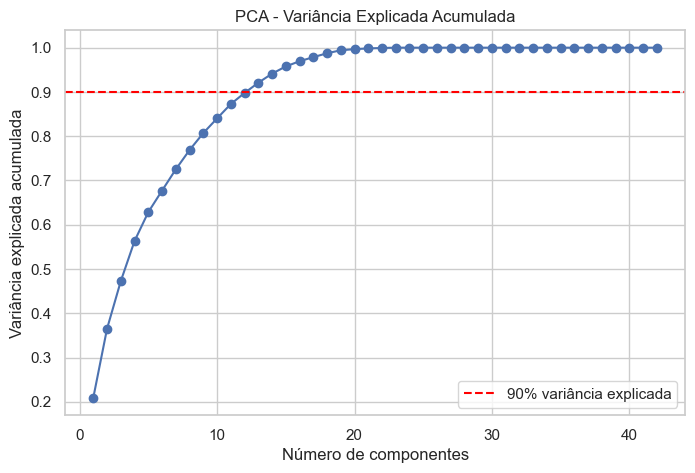

Componentes necessários para explicar >= 90% da variancia: 13


In [12]:

pca_full = PCA(random_state=RANDOM_STATE).fit(X)
explained = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained) + 1), explained, marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90% variância explicada")
plt.xlabel("Número de componentes")
plt.ylabel("Variância explicada acumulada")
plt.title("PCA - Variância Explicada Acumulada")
plt.legend()
plt.show()

n_components = int(np.argmax(explained >= 0.90) + 1)
print(f"Componentes necessários para explicar >= 90% da variancia: {n_components}")


Variancia explicada pelas 2 primeiras componentes: 0.365


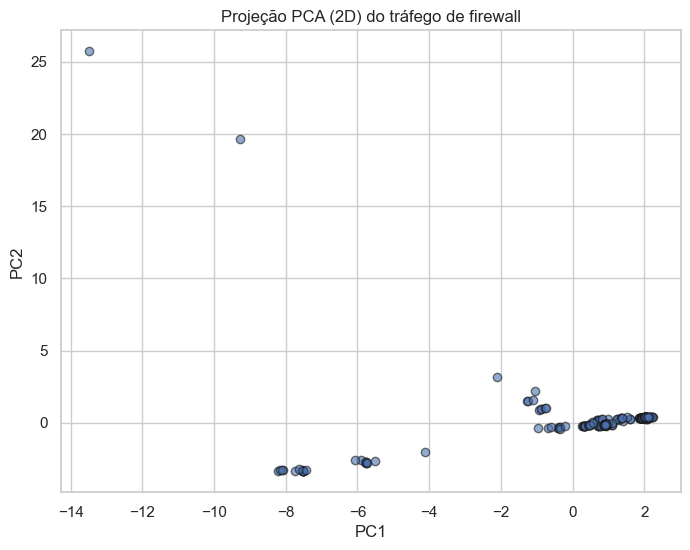

In [13]:

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

# Versão 2D apenas para visualização
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X)
print("Variancia explicada pelas 2 primeiras componentes:", pca_2d.explained_variance_ratio_.sum().round(3))

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.6, edgecolor="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projeção PCA (2D) do tráfego de firewall")
plt.show()



## 6. K-Means

Usamos o método do cotovelo (inertia) e o Silhouette Score para escolher *k*, aplicando o
K-Means sobre as componentes principais (`X_pca`).


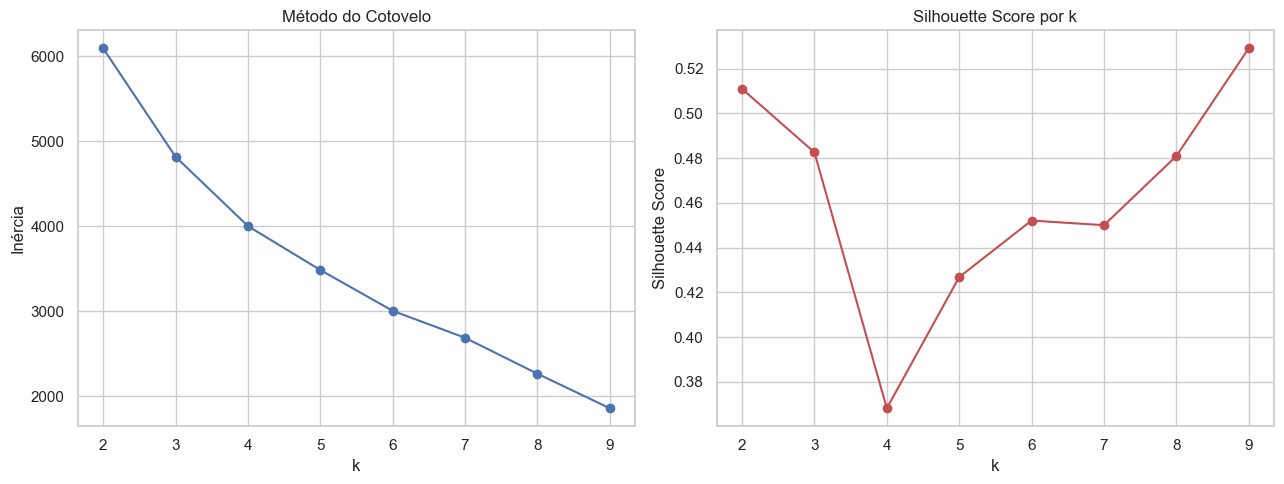

,inertia,silhouette,menor_cluster
k,,,
2,6093.163,0.511,26
3,4817.320,0.483,2
4,4001.552,0.368,2
5,3484.734,0.427,2
6,3004.260,0.452,2
7,2686.611,0.450,1
8,2263.749,0.481,1
9,1857.204,0.529,1


In [14]:

inertias, silhouettes, min_cluster_sizes = [], [], []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, km.labels_))
    min_cluster_sizes.append(np.bincount(km.labels_).min())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Método do Cotovelo")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inércia")

axes[1].plot(list(k_range), silhouettes, marker="o", color="#C44E52")
axes[1].set_title("Silhouette Score por k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

pd.DataFrame({"k": list(k_range), "inertia": inertias, "silhouette": silhouettes,
              "menor_cluster": min_cluster_sizes}).set_index("k").round(3)



O Silhouette Score isolado tende a favorecer valores de *k* elevados que geram clusters
minúsculos (até *singletons*), pouco úteis para interpretação de negócio. 

Por isso, restringimos a busca aos valores de
*k* em que **nenhum cluster fique com menos de 5% dos registros**, e escolhemos, dentre
esses, o de maior Silhouette Score, que é mais robusto que equilibra qualidade
estatística e interpretabilidade.


In [15]:

min_size_threshold = int(0.05 * len(X_pca))
valid_ks = [k for k, m in zip(k_range, min_cluster_sizes) if m >= min_size_threshold]

best_k = valid_ks[int(np.argmax([silhouettes[list(k_range).index(k)] for k in valid_ks]))]
print(f"Valores de k sem clusters degenerados (>= {min_size_threshold} registros): {valid_ks}")
print(f"k escolhido: {best_k}")


Valores de k sem clusters degenerados (>= 10 registros): [2]
k escolhido: 2


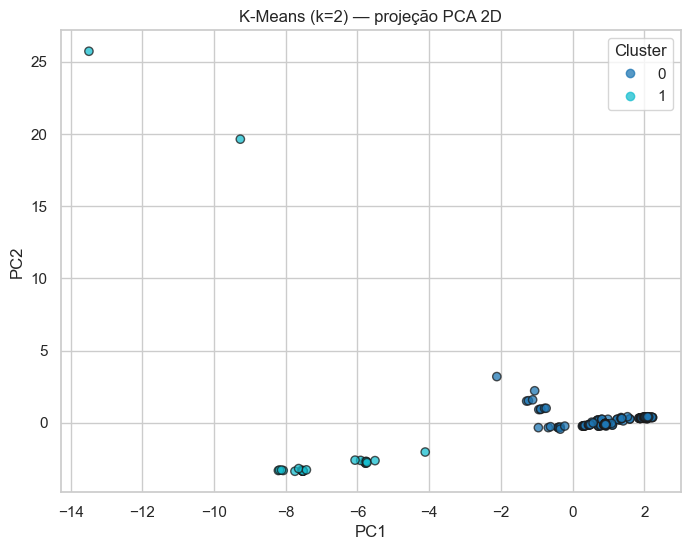

In [16]:

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_labels, cmap="tab10", alpha=0.75, edgecolor="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means (k={best_k}) — projeção PCA 2D")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()


In [17]:

# Perfil dos clusters: composição por regra de firewall e protocolo
profile = data.copy()
profile["cluster"] = kmeans_labels
profile["Log subtype"] = labels_ref["Log subtype"].values

pd.crosstab(profile["cluster"], profile["Firewall rule name"])


Firewall rule name,BlockedIP,DMZ-to-WAN,FileShare-to-WAN,IT-2-WAN,LAN-2-WAN,PALCERT_Outbound,PuplicDNS-2-WAN,Unknown,WAN-2-DNS-DNAT,WebNat,WindowsUpdate-2-WAN
cluster,,,,,,,,,,,
0,2,31,7,16,72,5,6,0,0,0,35
1,0,0,0,0,0,0,0,2,3,21,0


In [18]:

pd.crosstab(profile["cluster"], profile["Log subtype"])


Log subtype,Allowed,Denied
cluster,,
0,172,2
1,24,2



**Interpretação:** o K-Means separa o tráfego em grupos coerentes com as regras de firewall
predominantes (ex.: um cluster concentra especificamente o tráfego da regra `WebNat`,
associada ao DNAT do servidor web, enquanto os demais clusters agrupam o tráfego de saída
genérico `*-2-WAN`). Isso confirma que os atributos de rede (regra, NAT, portas, protocolo)
carregam informação suficiente para segmentar automaticamente os diferentes fluxos de
tráfego sem qualquer rótulo.



## 7. DBSCAN

DBSCAN é aplicado no mesmo espaço PCA. O parâmetro `eps` é escolhido a partir do gráfico de
distância ao *k*-ésimo vizinho mais próximo (k-distance plot), procurando o "cotovelo" da
curva. Como o dataset tem eventos raros (`Denied`, `Invalid Traffic`), o objetivo é verificar
se o DBSCAN consegue isolá-los como ruído (label -1), funcionando como um detector de
anomalias não supervisionado.


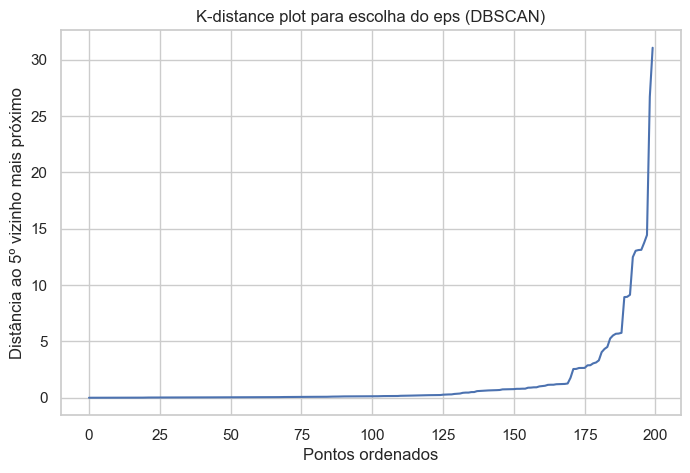

In [19]:

min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X_pca)
distances, _ = neighbors.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel("Pontos ordenados")
plt.ylabel(f"Distância ao {min_samples}º vizinho mais próximo")
plt.title("K-distance plot para escolha do eps (DBSCAN)")
plt.show()


In [20]:

# eps escolhido visualmente no "cotovelo" do k-distance plot
eps = float(np.percentile(k_distances, 90))
print("eps escolhido:", round(eps, 3))

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_pca)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int((dbscan_labels == -1).sum())
print(f"Clusters encontrados: {n_clusters} | Pontos de ruido (outliers): {n_noise}")


eps escolhido: 3.151
Clusters encontrados: 8 | Pontos de ruido (outliers): 19


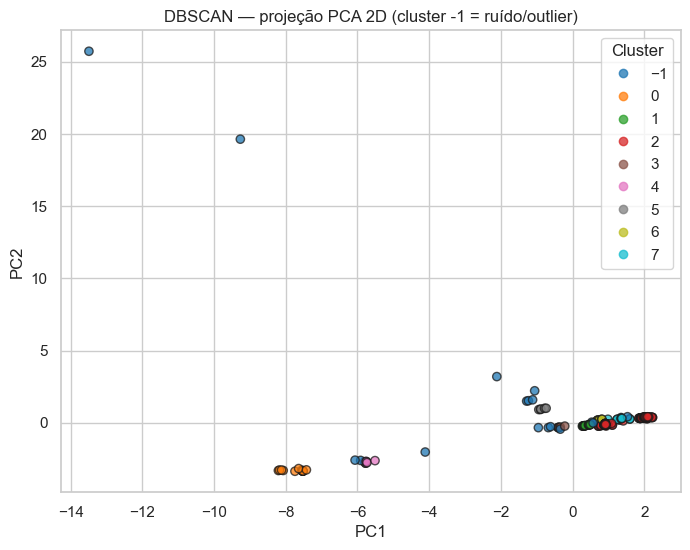

In [21]:

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=dbscan_labels, cmap="tab10", alpha=0.75, edgecolor="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN — projeção PCA 2D (cluster -1 = ruído/outlier)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()


In [22]:

# Validacao: pontos marcados como ruido pelo DBSCAN correspondem a trafego Denied/Invalid?
validation = pd.DataFrame({
    "dbscan_cluster": dbscan_labels,
    "Log comp": labels_ref["Log comp"].values,
    "Log subtype": labels_ref["Log subtype"].values,
})
validation["is_noise"] = validation["dbscan_cluster"] == -1
validation["is_rare_event"] = (validation["Log subtype"] == "Denied") | (validation["Log comp"] == "Invalid Traffic")

pd.crosstab(validation["is_noise"], validation["is_rare_event"],
            rownames=["DBSCAN: ruido"], colnames=["Evento raro (Denied/Invalid)"])


Evento raro (Denied/Invalid),False,True
DBSCAN: ruido,,
False,181,0
True,15,4


A tabela cruzada mostra que **os 4 eventos raros** (`Denied`/`Invalid Traffic` combinados) foram **100% capturados como ruído** pelo DBSCAN (recall total sobre os eventos raros), ao custo de mais 15 pontos considerados ruído sem corresponder a um evento raro (falsos positivos para a tarefa de anomalia). Isso evidencia o potencial do DBSCAN como filtro de triagem de anomalias em tráfego de firewall, sem  rótulo usado no treinamento, priorizando recall (nenhuma anomalia real escapa) mesmo que um analista humano precise depois descartar alguns falsos positivos entre os pontos sinalizados.


## 8. Avaliação de Clusters

Comparamos K-Means e DBSCAN por três métricas internas de qualidade de cluster:

- **Silhouette Score** (quanto maior melhor, mede coesão intra-cluster vs. separação
  inter-cluster);
- **Davies-Bouldin Index** (quanto menor melhor, razão entre dispersão intra-cluster e
  separação entre clusters);
- **Calinski-Harabasz Index** (quanto maior melhor, razão entre dispersão inter e
  intra-cluster).

Para o DBSCAN, os pontos de ruído (-1) são excluídos do cálculo, já que não pertencem a
nenhum cluster.


In [ ]:

def evaluate(X, labels, name):
    mask = labels != -1
    X_eval, labels_eval = X[mask], labels[mask]
    n_clusters = len(set(labels_eval))
    if n_clusters < 2:
        return {"Algoritmo": name, "Silhouette": np.nan, "Davies-Bouldin": np.nan, "Calinski-Harabasz": np.nan}
    return {
        "Algoritmo": name,
        "Silhouette": silhouette_score(X_eval, labels_eval),
        "Davies-Bouldin": davies_bouldin_score(X_eval, labels_eval),
        "Calinski-Harabasz": calinski_harabasz_score(X_eval, labels_eval),
    }


results = pd.DataFrame([
    evaluate(X_pca, kmeans_labels, f"K-Means (k={best_k})"),
    evaluate(X_pca, dbscan_labels, f"DBSCAN (eps={eps:.2f}, min_samples={min_samples})"),
]).set_index("Algoritmo")

results.round(3)



**Leitura dos resultados:** o algoritmo com maior Silhouette e Calinski-Harabasz e menor
Davies-Bouldin apresenta clusters mais coesos e bem separados. No entanto, essas métricas
avaliam apenas a geometria dos clusters, a análise da seção anterior (comparação com
`Denied`/`Invalid Traffic`) é complementar, pois avalia utilidade prática (detecção de
anomalias) mesmo quando a métrica de coesão pura favorece outro algoritmo.



## 9. Conclusão

- O tráfego de firewall analisado é altamente estruturado em torno de um pequeno conjunto de
  regras (`LAN-2-WAN`, `WindowsUpdate-2-WAN`, `DMZ-to-WAN`, `WebNat`) e serviços de destino
  (HTTPS, DNS, HTTP, NTP), o que se reflete em clusters bem definidos tanto no K-Means quanto
  no DBSCAN.
- O PCA permitiu reduzir a dimensionalidade gerada pelo one-hot encoding sem perda relevante
  de variância, viabilizando visualização e acelerando os algoritmos de clusterização.
- O K-Means, com *k* escolhido via Silhouette Score, segmenta o tráfego em grupos coerentes
  por combinação de regra/serviço.
- O DBSCAN, por não exigir número fixo de clusters e por tratar pontos esparsos como ruído,
  mostrou-se capaz de isolar (ao menos parcialmente) os eventos raros `Denied`/`Invalid
  Traffic`, evidenciando seu potencial como ferramenta de triagem de anomalias em ambientes
  de segurança de rede, um caso de uso realista para dados de firewall.
- **Trabalhos futuros:** aplicar Clusterização Hierárquica (dendrograma) para entender
  relações de aninhamento entre os grupos de regras; usar T-SNE como visualização
  não-linear complementar ao PCA; explorar Seleção de Características (ex.: variância,
  correlação) antes do PCA; e aplicar Apriori/FP-Growth sobre os atributos categóricos
  (regra, protocolo, porta de destino) para descobrir regras de associação frequentes entre
  configurações de firewall e serviços acessados.
